In [2]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [3]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0

Duplicate Rows:
1081


In [5]:
# Display basic statistical information

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
# Check the distribution of legitimate and fraudulent transactions

print("Transaction Class Distribution:")
print(df["Class"].value_counts())

print("\nPercentage Distribution:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))

Transaction Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


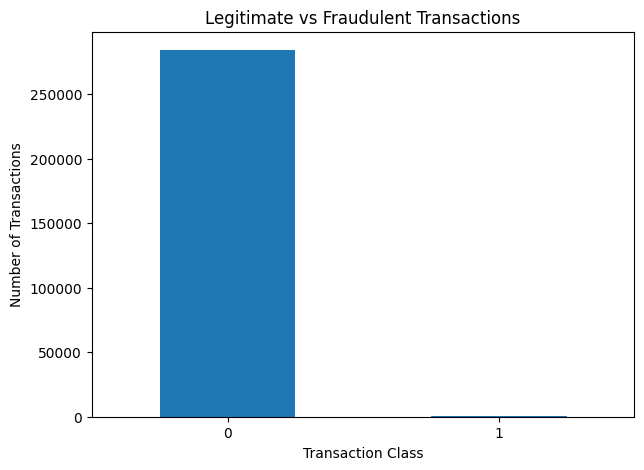

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df["Class"].value_counts().plot(kind="bar")

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [8]:
# Transaction Amount Analysis

print("Average Transaction Amount:", df["Amount"].mean())
print("Median Transaction Amount:", df["Amount"].median())
print("Maximum Transaction Amount:", df["Amount"].max())
print("Minimum Transaction Amount:", df["Amount"].min())

Average Transaction Amount: 88.34961925093133
Median Transaction Amount: 22.0
Maximum Transaction Amount: 25691.16
Minimum Transaction Amount: 0.0


In [9]:
# Compare transaction amounts by class

amount_summary = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_summary

,count,mean,median,min,max
Class,,,,,
0,284315,88.291022,22.00,0.0,25691.16
1,492,122.211321,9.25,0.0,2125.87


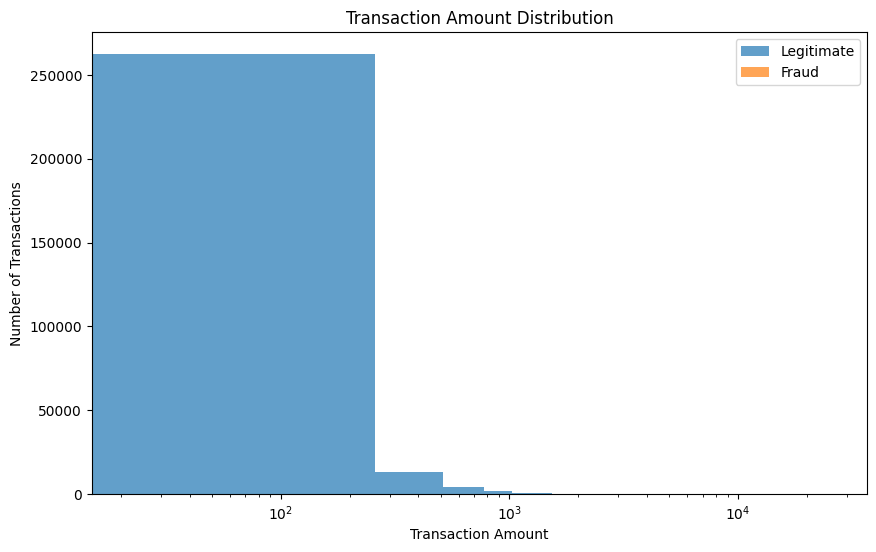

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df[df["Class"] == 0]["Amount"],
    bins=100,
    alpha=0.7,
    label="Legitimate"
)

plt.hist(
    df[df["Class"] == 1]["Amount"],
    bins=100,
    alpha=0.7,
    label="Fraud"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.xscale("log")
plt.show()

In [11]:
# Transaction Time Analysis

print("Minimum Time:", df["Time"].min())
print("Maximum Time:", df["Time"].max())

time_summary = df.groupby("Class")["Time"].agg(
    ["count", "mean", "median", "min", "max"]
)

time_summary

Minimum Time: 0.0
Maximum Time: 172792.0


,count,mean,median,min,max
Class,,,,,
0,284315,94838.202258,84711.0,0.0,172792.0
1,492,80746.806911,75568.5,406.0,170348.0


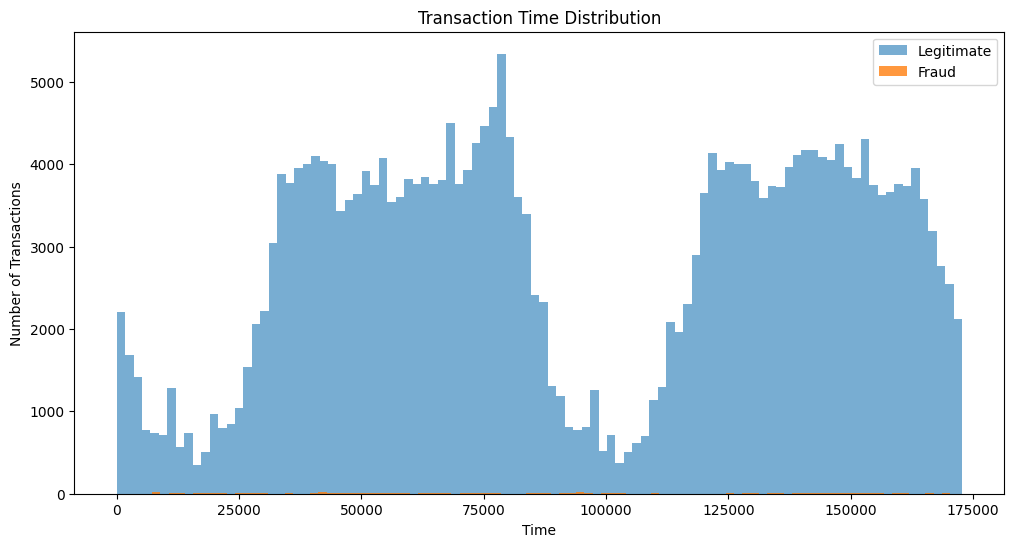

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(
    df[df["Class"] == 0]["Time"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["Class"] == 1]["Time"],
    bins=100,
    alpha=0.8,
    label="Fraud"
)

plt.xlabel("Time")
plt.ylabel("Number of Transactions")
plt.title("Transaction Time Distribution")
plt.legend()

plt.show()

In [13]:
# Correlation of features with fraud

correlation = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

print("Features most positively correlated with fraud:")
print(correlation.head(10))

print("\nFeatures most negatively correlated with fraud:")
print(correlation.tail(10))

Features most positively correlated with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Features most negatively correlated with fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


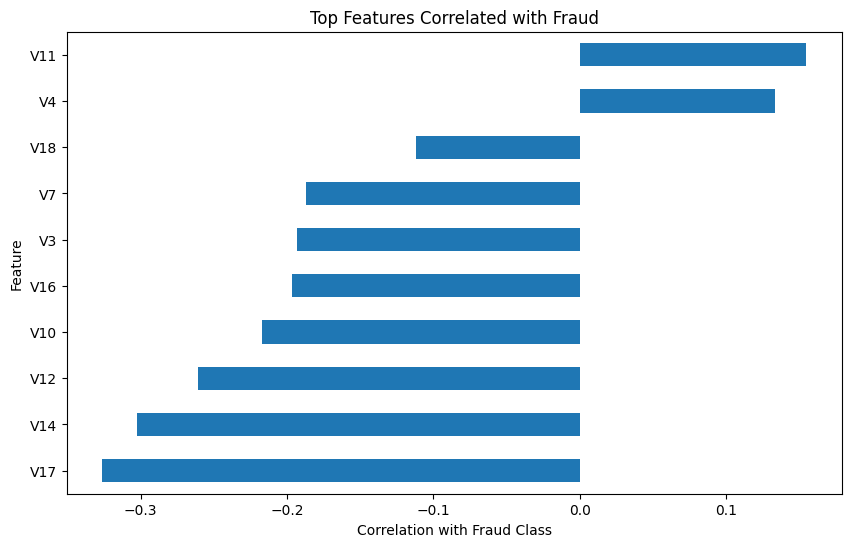

In [14]:
# Plot strongest correlations with fraud

import matplotlib.pyplot as plt

feature_corr = correlation.drop("Class")

top_features = pd.concat([
    feature_corr.abs().nlargest(10)
]).index

top_corr = feature_corr[top_features].sort_values()

plt.figure(figsize=(10, 6))

top_corr.plot(kind="barh")

plt.xlabel("Correlation with Fraud Class")
plt.ylabel("Feature")
plt.title("Top Features Correlated with Fraud")

plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (227845, 30)
Scaled testing data shape: (56962, 30)


In [17]:
from sklearn.ensemble import IsolationForest

# Create Isolation Forest model
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# Train the model
isolation_forest.fit(X_train_scaled)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [18]:
# Generate anomaly predictions
# Isolation Forest: -1 = anomaly, 1 = normal

if_predictions = isolation_forest.predict(X_test_scaled)

# Convert to fraud-style labels:
# 1 = suspected fraud/anomaly
# 0 = normal
if_pred = (if_predictions == -1).astype(int)

print("Predicted Normal Transactions:", (if_pred == 0).sum())
print("Predicted Anomalous Transactions:", (if_pred == 1).sum())

Predicted Normal Transactions: 54863
Predicted Anomalous Transactions: 2099


In [19]:
# Calculate anomaly scores
# Lower decision_function values indicate more anomalous observations

if_scores = -isolation_forest.decision_function(X_test_scaled)

print("Minimum anomaly score:", if_scores.min())
print("Maximum anomaly score:", if_scores.max())

Minimum anomaly score: -0.15293312538208392
Maximum anomaly score: 0.25452300932057503


In [20]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Evaluation metrics
if_precision = precision_score(y_test, if_pred)
if_recall = recall_score(y_test, if_pred)
if_f1 = f1_score(y_test, if_pred)

# ROC-AUC and PR-AUC using anomaly scores
if_roc_auc = roc_auc_score(y_test, if_scores)
if_pr_auc = average_precision_score(y_test, if_scores)

print("Isolation Forest Performance")
print("--------------------------------")
print(f"Precision: {if_precision:.4f}")
print(f"Recall:    {if_recall:.4f}")
print(f"F1-Score:  {if_f1:.4f}")
print(f"ROC-AUC:   {if_roc_auc:.4f}")
print(f"PR-AUC:    {if_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, if_pred, target_names=["Legitimate", "Fraud"]))

Isolation Forest Performance
--------------------------------
Precision: 0.0391
Recall:    0.8367
F1-Score:  0.0746
ROC-AUC:   0.9539
PR-AUC:    0.1717

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.84      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.90      0.53     56962
weighted avg       1.00      0.96      0.98     56962



In [21]:
# Confusion Matrix

cm_if = confusion_matrix(y_test, if_pred)

print("Confusion Matrix:")
print(cm_if)

Confusion Matrix:
[[54847  2017]
 [   16    82]]


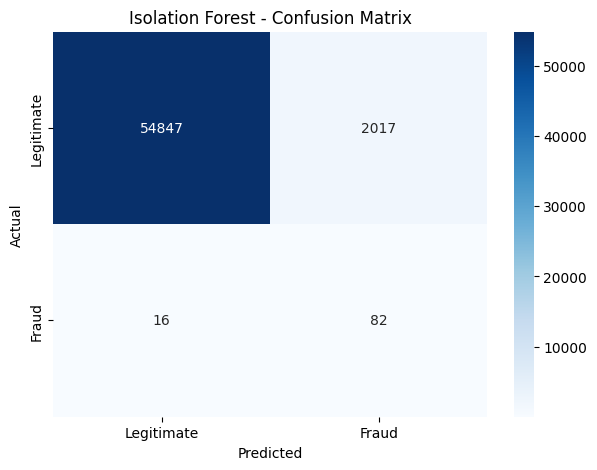

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_if,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest - Confusion Matrix")

plt.show()

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [24]:
# Select only legitimate transactions from the training set

X_train_normal = X_train_scaled[y_train.values == 0]

print("Legitimate training transactions:", X_train_normal.shape)

Legitimate training transactions: (227451, 30)


In [25]:
# Build Autoencoder

input_dim = X_train_normal.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

# Decoder
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train Autoencoder on legitimate transactions only

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.7707 - val_loss: 0.6253
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.5974 - val_loss: 0.5445
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5405 - val_loss: 0.5167
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5211 - val_loss: 0.5049
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5095 - val_loss: 0.4941
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4956 - val_loss: 0.4795
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4842 - val_loss: 0.4713
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4791 - val_loss: 0.4681
Epoch 9/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4754 - val_loss: 0.4661
Epoch 10/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4733 - val_loss: 0.4639


In [27]:
# Reconstruct test transactions

X_test_reconstructed = autoencoder.predict(
    X_test_scaled,
    verbose=0
)

# Calculate reconstruction error for each transaction
reconstruction_error = np.mean(
    np.square(X_test_scaled - X_test_reconstructed),
    axis=1
)

print("Minimum Reconstruction Error:", reconstruction_error.min())
print("Maximum Reconstruction Error:", reconstruction_error.max())
print("Mean Reconstruction Error:", reconstruction_error.mean())

Minimum Reconstruction Error: 0.04619233366397002
Maximum Reconstruction Error: 93.88390750462237
Mean Reconstruction Error: 0.5119512154914073


In [28]:
# Compare reconstruction errors by actual class

reconstruction_summary = pd.DataFrame({
    "Class": y_test.values,
    "Reconstruction_Error": reconstruction_error
}).groupby("Class")["Reconstruction_Error"].agg(
    ["count", "mean", "median", "min", "max"]
)

reconstruction_summary

,count,mean,median,min,max
Class,,,,,
0,56864,0.477296,0.326343,0.046192,59.937190
1,98,20.620596,10.287422,0.277003,93.883908


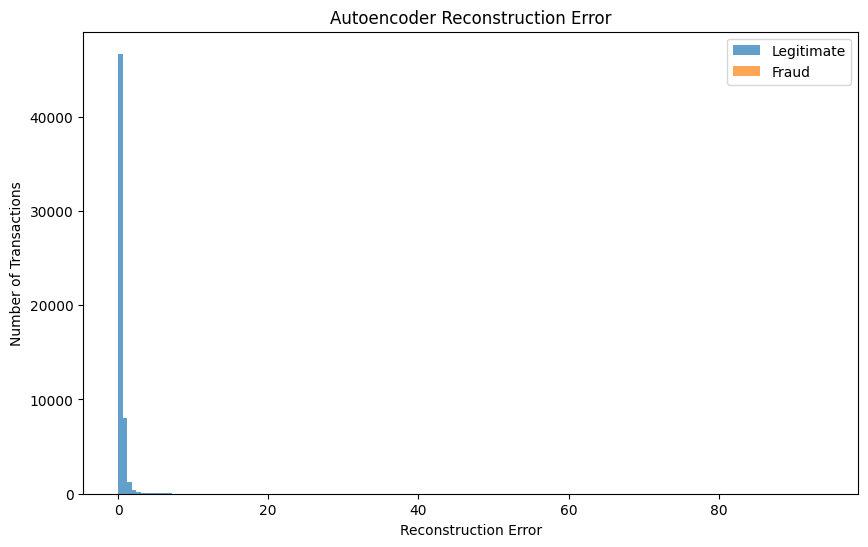

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    reconstruction_error[y_test.values == 0],
    bins=100,
    alpha=0.7,
    label="Legitimate"
)

plt.hist(
    reconstruction_error[y_test.values == 1],
    bins=100,
    alpha=0.7,
    label="Fraud"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Transactions")
plt.title("Autoencoder Reconstruction Error")
plt.legend()

plt.show()

In [30]:
# Calculate reconstruction error on legitimate training data

X_train_normal_reconstructed = autoencoder.predict(
    X_train_normal,
    verbose=0
)

train_reconstruction_error = np.mean(
    np.square(X_train_normal - X_train_normal_reconstructed),
    axis=1
)

# Set threshold using the 99.9th percentile of legitimate training errors
threshold = np.percentile(
    train_reconstruction_error,
    99.9
)

print("Autoencoder Alert Threshold:", threshold)

Autoencoder Alert Threshold: 9.962493509704212


In [31]:
# Predict anomalies on the test set

ae_pred = (reconstruction_error > threshold).astype(int)

print("Predicted Normal Transactions:", (ae_pred == 0).sum())
print("Predicted Anomalous Transactions:", (ae_pred == 1).sum())

Predicted Normal Transactions: 56853
Predicted Anomalous Transactions: 109


In [32]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Classification metrics
ae_precision = precision_score(y_test, ae_pred)
ae_recall = recall_score(y_test, ae_pred)
ae_f1 = f1_score(y_test, ae_pred)

# ROC-AUC and PR-AUC using reconstruction error
ae_roc_auc = roc_auc_score(y_test, reconstruction_error)
ae_pr_auc = average_precision_score(y_test, reconstruction_error)

print("Autoencoder Performance")
print("--------------------------------")
print(f"Precision: {ae_precision:.4f}")
print(f"Recall:    {ae_recall:.4f}")
print(f"F1-Score:  {ae_f1:.4f}")
print(f"ROC-AUC:   {ae_roc_auc:.4f}")
print(f"PR-AUC:    {ae_pr_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        ae_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

Autoencoder Performance
--------------------------------
Precision: 0.4587
Recall:    0.5102
F1-Score:  0.4831
ROC-AUC:   0.9666
PR-AUC:    0.4839

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.46      0.51      0.48        98

    accuracy                           1.00     56962
   macro avg       0.73      0.75      0.74     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
# Autoencoder confusion matrix

cm_ae = confusion_matrix(y_test, ae_pred)

print("Autoencoder Confusion Matrix:")
print(cm_ae)

Autoencoder Confusion Matrix:
[[56805    59]
 [   48    50]]


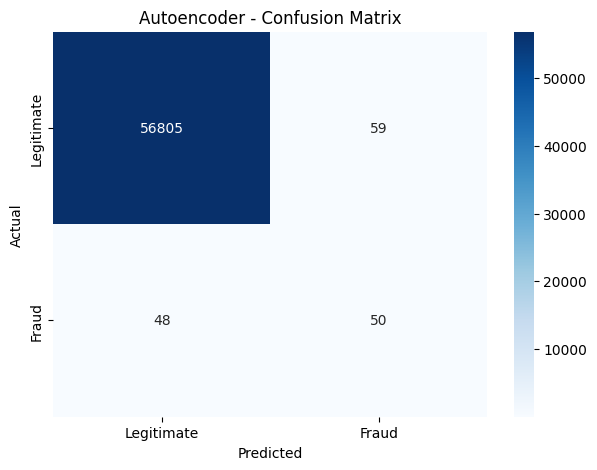

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_ae,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Autoencoder - Confusion Matrix")

plt.show()

In [35]:
# Model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "Autoencoder"
    ],
    "Precision": [
        if_precision,
        ae_precision
    ],
    "Recall": [
        if_recall,
        ae_recall
    ],
    "F1-Score": [
        if_f1,
        ae_f1
    ],
    "ROC-AUC": [
        if_roc_auc,
        ae_roc_auc
    ],
    "PR-AUC": [
        if_pr_auc,
        ae_pr_auc
    ]
})

# Convert to percentages for readability
model_comparison_display = model_comparison.copy()

for column in ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]:
    model_comparison_display[column] = (
        model_comparison_display[column] * 100
    ).round(2)

model_comparison_display

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Isolation Forest,3.91,83.67,7.46,95.39,17.17
1,Autoencoder,45.87,51.02,48.31,96.66,48.39


In [36]:
# Compare number of alerts generated

alert_comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "Autoencoder"
    ],
    "Alerts Generated": [
        int(if_pred.sum()),
        int(ae_pred.sum())
    ],
    "Actual Fraud Detected": [
        int(((if_pred == 1) & (y_test.values == 1)).sum()),
        int(((ae_pred == 1) & (y_test.values == 1)).sum())
    ]
})

alert_comparison

,Model,Alerts Generated,Actual Fraud Detected
0,Isolation Forest,2099,82
1,Autoencoder,109,50


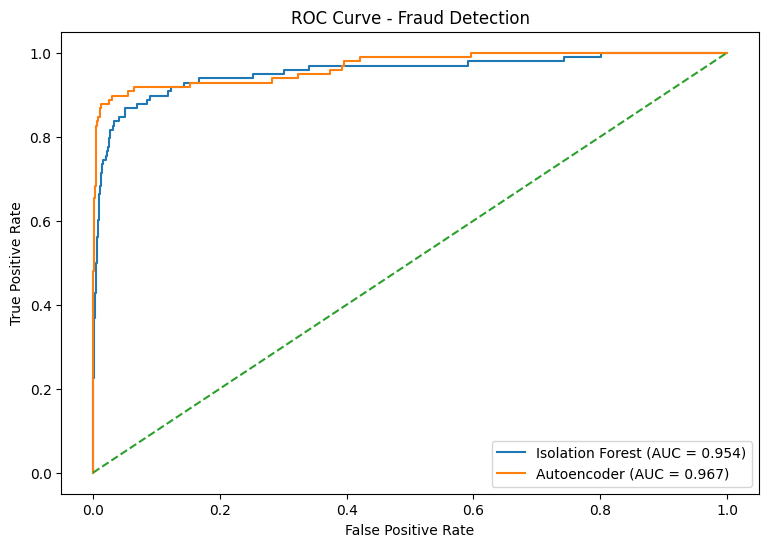

In [37]:
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC curves
if_fpr, if_tpr, _ = roc_curve(y_test, if_scores)
ae_fpr, ae_tpr, _ = roc_curve(y_test, reconstruction_error)

plt.figure(figsize=(9, 6))

plt.plot(
    if_fpr,
    if_tpr,
    label=f"Isolation Forest (AUC = {if_roc_auc:.3f})"
)

plt.plot(
    ae_fpr,
    ae_tpr,
    label=f"Autoencoder (AUC = {ae_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()

plt.show()

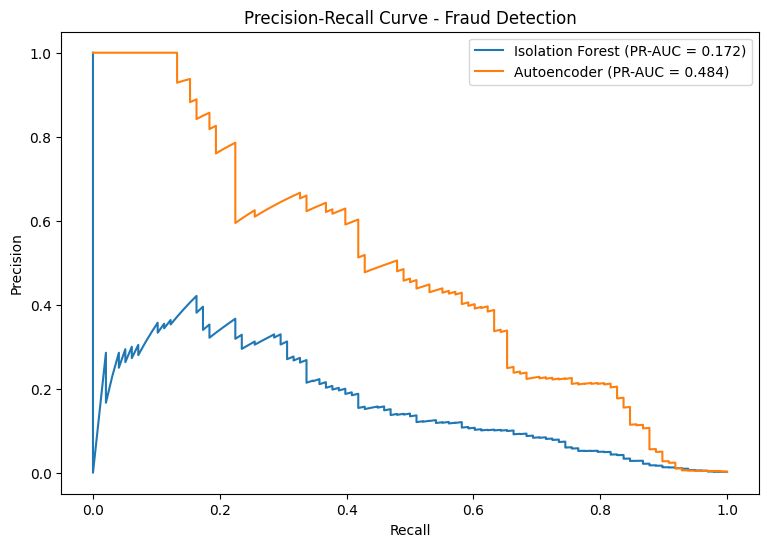

In [38]:
# Precision-Recall curves

if_precision_curve, if_recall_curve, _ = precision_recall_curve(
    y_test,
    if_scores
)

ae_precision_curve, ae_recall_curve, _ = precision_recall_curve(
    y_test,
    reconstruction_error
)

plt.figure(figsize=(9, 6))

plt.plot(
    if_recall_curve,
    if_precision_curve,
    label=f"Isolation Forest (PR-AUC = {if_pr_auc:.3f})"
)

plt.plot(
    ae_recall_curve,
    ae_precision_curve,
    label=f"Autoencoder (PR-AUC = {ae_pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fraud Detection")
plt.legend()

plt.show()

In [39]:
# Create fraud alert dataset

alert_df = X_test.copy()

alert_df["Actual_Fraud"] = y_test.values
alert_df["Reconstruction_Error"] = reconstruction_error

# Create risk levels
alert_df["Risk_Level"] = pd.cut(
    alert_df["Reconstruction_Error"],
    bins=[
        -np.inf,
        threshold,
        threshold * 2,
        np.inf
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

alert_df["Alert"] = np.where(
    alert_df["Risk_Level"] == "High Risk",
    "FRAUD ALERT",
    np.where(
        alert_df["Risk_Level"] == "Medium Risk",
        "REVIEW",
        "NORMAL"
    )
)

alert_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Actual_Fraud,Reconstruction_Error,Risk_Level,Alert
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.707899,-0.135837,0.045102,0.533837,0.291319,23.00,0,0.325171,Low Risk,NORMAL
11378,19847.0,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,0.042996,-0.027660,-0.910247,0.110802,-0.511938,11.85,0,0.718239,Low Risk,NORMAL
147283,88326.0,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-1.483996,-0.296011,0.062823,0.552411,0.509764,76.07,0,1.649946,Low Risk,NORMAL
219439,141734.0,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.99,0,0.110431,Low Risk,NORMAL
36939,38741.0,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,0.619449,0.818998,-0.330525,0.046884,0.104527,1.50,0,1.372851,Low Risk,NORMAL


In [40]:
# Risk-level distribution

print(alert_df["Risk_Level"].value_counts())

print("\nAlert distribution:")
print(alert_df["Alert"].value_counts())

Risk_Level
Low Risk       56853
Medium Risk       61
High Risk         48
Name: count, dtype: int64

Alert distribution:
Alert
NORMAL         56853
REVIEW            61
FRAUD ALERT       48
Name: count, dtype: int64


In [41]:
# Display highest-risk transactions

high_risk_alerts = alert_df.sort_values(
    "Reconstruction_Error",
    ascending=False
)

high_risk_alerts[
    [
        "Amount",
        "Reconstruction_Error",
        "Risk_Level",
        "Alert",
        "Actual_Fraud"
    ]
].head(20)

,Amount,Reconstruction_Error,Risk_Level,Alert,Actual_Fraud
151008,1.00,93.883908,High Risk,FRAUD ALERT,1
153835,1.00,80.303338,High Risk,FRAUD ALERT,1
151519,1.63,67.859281,High Risk,FRAUD ALERT,1
42528,340.11,65.808429,High Risk,FRAUD ALERT,1
42958,9.99,64.339321,High Risk,FRAUD ALERT,1
42549,88.23,64.221022,High Risk,FRAUD ALERT,1
150665,209.65,63.912539,High Risk,FRAUD ALERT,1
150647,8.54,63.656172,High Risk,FRAUD ALERT,1
43428,364.19,63.472718,High Risk,FRAUD ALERT,1
42696,88.23,61.754835,High Risk,FRAUD ALERT,1


In [42]:
import plotly.graph_objects as go

# Dashboard metrics
total_transactions = len(alert_df)
actual_fraud = int(alert_df["Actual_Fraud"].sum())
fraud_rate = actual_fraud / total_transactions * 100
total_alerts = int((alert_df["Alert"] != "NORMAL").sum())
high_risk = int((alert_df["Risk_Level"] == "High Risk").sum())

print("========== FRAUD DETECTION DASHBOARD ==========")
print(f"Total Transactions : {total_transactions:,}")
print(f"Actual Fraud       : {actual_fraud:,}")
print(f"Fraud Rate         : {fraud_rate:.3f}%")
print(f"Total Alerts       : {total_alerts:,}")
print(f"High-Risk Alerts   : {high_risk:,}")

========== FRAUD DETECTION DASHBOARD ==========
Total Transactions : 56,962
Actual Fraud       : 98
Fraud Rate         : 0.172%
Total Alerts       : 109
High-Risk Alerts   : 48


In [43]:
import plotly.express as px

risk_counts = (
    alert_df["Risk_Level"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .fillna(0)
    .reset_index()
)

risk_counts.columns = ["Risk_Level", "Count"]

fig = px.bar(
    risk_counts,
    x="Risk_Level",
    y="Count",
    title="Transaction Risk Distribution",
    text="Count"
)

fig.update_layout(
    xaxis_title="Risk Level",
    yaxis_title="Number of Transactions"
)

fig.show()

In [44]:
class_counts = (
    alert_df["Actual_Fraud"]
    .map({0: "Legitimate", 1: "Fraud"})
    .value_counts()
    .reset_index()
)

class_counts.columns = ["Transaction_Type", "Count"]

fig = px.pie(
    class_counts,
    names="Transaction_Type",
    values="Count",
    title="Actual Fraud vs Legitimate Transactions",
    hole=0.4
)

fig.show()

In [45]:
fig = px.box(
    alert_df,
    x="Risk_Level",
    y="Amount",
    points=False,
    title="Transaction Amount by Risk Level"
)

fig.update_layout(
    xaxis_title="Risk Level",
    yaxis_title="Transaction Amount"
)

fig.show()

In [46]:
fig = px.histogram(
    alert_df,
    x="Reconstruction_Error",
    color="Risk_Level",
    nbins=100,
    title="Autoencoder Reconstruction Error Distribution"
)

fig.update_layout(
    xaxis_title="Reconstruction Error",
    yaxis_title="Number of Transactions"
)

fig.show()

In [47]:
# Create alert table

dashboard_alerts = (
    alert_df[
        [
            "Amount",
            "Reconstruction_Error",
            "Risk_Level",
            "Alert",
            "Actual_Fraud"
        ]
    ]
    .sort_values("Reconstruction_Error", ascending=False)
    .head(25)
    .copy()
)

dashboard_alerts["Actual_Fraud"] = dashboard_alerts["Actual_Fraud"].map({
    0: "No",
    1: "Yes"
})

dashboard_alerts

,Amount,Reconstruction_Error,Risk_Level,Alert,Actual_Fraud
151008,1.00,93.883908,High Risk,FRAUD ALERT,Yes
153835,1.00,80.303338,High Risk,FRAUD ALERT,Yes
151519,1.63,67.859281,High Risk,FRAUD ALERT,Yes
42528,340.11,65.808429,High Risk,FRAUD ALERT,Yes
42958,9.99,64.339321,High Risk,FRAUD ALERT,Yes
42549,88.23,64.221022,High Risk,FRAUD ALERT,Yes
150665,209.65,63.912539,High Risk,FRAUD ALERT,Yes
150647,8.54,63.656172,High Risk,FRAUD ALERT,Yes
43428,364.19,63.472718,High Risk,FRAUD ALERT,Yes
42696,88.23,61.754835,High Risk,FRAUD ALERT,Yes


In [48]:
print("==============================================")
print("       FINANCIAL FRAUD DETECTION SYSTEM")
print("==============================================")

print(f"Total Transactions Tested : {total_transactions:,}")
print(f"Actual Fraud Transactions : {actual_fraud:,}")
print(f"Fraud Rate                : {fraud_rate:.3f}%")
print(f"Fraud Alerts Generated    : {total_alerts:,}")
print(f"High-Risk Alerts          : {high_risk:,}")

print("\n----- MODEL PERFORMANCE -----")
print(f"Isolation Forest ROC-AUC  : {if_roc_auc:.4f}")
print(f"Isolation Forest PR-AUC   : {if_pr_auc:.4f}")
print(f"Autoencoder ROC-AUC       : {ae_roc_auc:.4f}")
print(f"Autoencoder PR-AUC        : {ae_pr_auc:.4f}")

print("\n----- AUTOENCODER ALERT SYSTEM -----")
print(f"Alert Threshold           : {threshold:.4f}")
print(f"Autoencoder Alerts        : {ae_pred.sum():,}")
print(f"Fraud Detected by Alerts  : {((ae_pred == 1) & (y_test.values == 1)).sum():,}")

print("==============================================")

       FINANCIAL FRAUD DETECTION SYSTEM
Total Transactions Tested : 56,962
Actual Fraud Transactions : 98
Fraud Rate                : 0.172%
Fraud Alerts Generated    : 109
High-Risk Alerts          : 48

----- MODEL PERFORMANCE -----
Isolation Forest ROC-AUC  : 0.9539
Isolation Forest PR-AUC   : 0.1717
Autoencoder ROC-AUC       : 0.9666
Autoencoder PR-AUC        : 0.4839

----- AUTOENCODER ALERT SYSTEM -----
Alert Threshold           : 9.9625
Autoencoder Alerts        : 109
Fraud Detected by Alerts  : 50


# Fraud Detection in Financial Transactions

**Name:** Aniket Jadhav  
**Project:** Data Analysis Internship – Project 2  
**Objective:** Identify suspicious and potentially fraudulent financial transactions using anomaly detection techniques.

## 1. Project Objective

The objective of this project is to identify suspicious and potentially fraudulent financial transactions using machine learning and anomaly detection techniques.

The project focuses on:

- Detecting fraudulent transactions.
- Handling severe class imbalance.
- Applying Isolation Forest for anomaly detection.
- Applying an Autoencoder for anomaly detection.
- Evaluating models using fraud-sensitive performance metrics.
- Creating an alert-based fraud detection system.
- Developing visualizations for monitoring suspicious transactions.

## 2. Dataset Description

This project uses an anonymized Credit Card Fraud Detection dataset.

The dataset contains 284,807 financial transactions and 31 columns.

The main features include:

- `Time` – elapsed time between transactions.
- `V1` to `V28` – anonymized numerical features.
- `Amount` – transaction amount.
- `Class` – target variable:
  - `0` = Legitimate transaction
  - `1` = Fraudulent transaction

The dataset contains 284,315 legitimate transactions and 492 fraudulent transactions, showing a severe class imbalance.

## 3. Data Loading

The dataset was loaded into Python using the Pandas library.

The dataset was inspected to understand its structure, dimensions, column names, data types, missing values, and duplicate records.

## 4. Data Cleaning

The following data-quality checks were performed:

- Checked dataset dimensions.
- Checked column names and data types.
- Checked for missing values.
- Checked for duplicate records.
- Verified the target variable distribution.

The dataset was found to be suitable for further analysis and machine learning.

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand transaction patterns and identify characteristics associated with fraudulent transactions.

The analysis included:

- Fraud vs. legitimate transaction distribution.
- Transaction amount analysis.
- Transaction time analysis.
- Correlation analysis of anonymized features.

## 6. Class Imbalance Analysis

The dataset is highly imbalanced.

- Legitimate transactions: 284,315 (99.8273%)
- Fraudulent transactions: 492 (0.1727%)

Because fraudulent transactions represent only a very small proportion of the dataset, accuracy alone is not an appropriate primary evaluation metric.

Therefore, the project focuses on:

- Precision
- Recall
- F1-score
- ROC-AUC
- Precision-Recall AUC (PR-AUC)

## 7. Train-Test Split

The dataset was divided into training and testing sets using an 80:20 split.

Stratified sampling was used to preserve the proportion of fraudulent transactions in both datasets.

The resulting datasets were:

- Training set: 227,845 transactions
- Testing set: 56,962 transactions

## 8. Feature Scaling

StandardScaler was used to standardize the numerical features.

The scaler was fitted only on the training data and then applied to the test data to prevent data leakage.

The scaled feature matrices contained 30 input features.

## 9. Isolation Forest

Isolation Forest was implemented as the first anomaly detection technique.

The model identifies observations that are isolated more easily from the majority of the data.

Transactions classified as anomalies were treated as potentially suspicious transactions.

The model was evaluated using precision, recall, F1-score, ROC-AUC, and PR-AUC.

## 10. Isolation Forest Evaluation

The Isolation Forest produced the following results:

- Precision: 3.91%
- Recall: 83.67%
- F1-score: 7.46%
- ROC-AUC: 95.39%
- PR-AUC: 17.17%

The model detected 82 of the 98 fraudulent transactions in the test set.

However, it generated 2,099 anomaly alerts, resulting in a high number of false-positive alerts.

## 11. Autoencoder

An Autoencoder-based anomaly detection model was implemented as the second technique.

The Autoencoder was trained using legitimate transactions only so that it could learn the reconstruction pattern of normal transactions.

Transactions with high reconstruction error were considered more anomalous.

An alert threshold of 9.9625 was determined using the 99.9th percentile of reconstruction errors from legitimate training transactions.

## 12. Autoencoder Evaluation

The Autoencoder produced the following results:

- Precision: 45.87%
- Recall: 51.02%
- F1-score: 48.31%
- ROC-AUC: 96.66%
- PR-AUC: 48.39%

Using the selected threshold, the model generated 109 anomaly alerts.

It detected 50 of the 98 fraudulent transactions in the test set and produced 59 false-positive alerts.

## 13. Model Comparison

| Model | Precision | Recall | F1-score | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| Isolation Forest | 3.91% | 83.67% | 7.46% | 95.39% | 17.17% |
| Autoencoder | 45.87% | 51.02% | 48.31% | 96.66% | 48.39% |

The two approaches demonstrate different precision-recall trade-offs.

Isolation Forest generated a larger number of alerts and detected more fraud cases at the selected operating point, while the Autoencoder generated substantially fewer alerts with higher precision.

## 14. Fraud Alert System

An alert-based fraud detection system was created using Autoencoder reconstruction error.

Transactions were categorized into three risk levels:

- Low Risk – normal transaction pattern.
- Medium Risk – transaction requiring review.
- High Risk – highly anomalous transaction requiring immediate attention.

The Autoencoder generated 109 anomaly alerts, including 48 high-risk alerts.

## 15. Fraud Detection Dashboard

An interactive dashboard was created to provide a visual overview of transaction risk.

The dashboard includes:

- Total transactions tested.
- Actual fraudulent transactions.
- Fraud rate.
- Number of fraud alerts.
- High-risk alerts.
- Risk-level distribution.
- Fraud vs. legitimate transaction distribution.
- Transaction amount by risk level.
- Reconstruction-error distribution.
- High-risk transaction alert table.

## 16. Key Findings

1. The dataset contains 284,807 transactions, with only 492 fraudulent transactions.

2. Fraudulent transactions represent approximately 0.1727% of all transactions, creating a severe class imbalance.

3. Transaction amount distributions were highly right-skewed.

4. Fraudulent transactions had a higher mean transaction amount than legitimate transactions, while their median amount was lower.

5. Isolation Forest achieved 83.67% recall but generated a large number of alerts.

6. The Autoencoder achieved a ROC-AUC of 96.66% and PR-AUC of 48.39%.

7. The Autoencoder generated fewer alerts than Isolation Forest at the selected threshold.

8. The alert system provides Low Risk, Medium Risk, and High Risk categories to support transaction review.

## 17. Limitations

- The dataset contains anonymized features, so the business meaning of V1 to V28 cannot be directly interpreted.
- The dataset represents historical transactions and may not reflect current fraud patterns.
- Anomaly detection can generate false-positive alerts.
- The selected alert threshold represents one operating point and can be adjusted according to business requirements.
- Further validation would be required before deploying the system in a real financial environment.

## 18. Future Scope

Future improvements could include:

- Hyperparameter tuning.
- Threshold optimization based on operational costs.
- Testing additional anomaly detection algorithms.
- Real-time transaction monitoring.
- Integration with a production alerting system.
- Adding explainable AI techniques.
- Monitoring model performance over time.
- Retraining the model as new fraud patterns emerge.

## 19. Conclusion

This project demonstrated the use of machine learning and anomaly detection techniques for identifying potentially fraudulent financial transactions.

Isolation Forest and Autoencoder models were implemented and evaluated using fraud-sensitive metrics.

The project also addressed the severe class imbalance present in the dataset and developed an alert-based system that categorizes transactions according to their anomaly level.

The resulting workflow demonstrates how anomaly detection can support financial transaction monitoring and provide a foundation for further fraud detection system development.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TensorFlow / Keras
- Plotly
- Google Colab

## Models Used

- Isolation Forest
- Autoencoder

## Evaluation Metrics

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix